In [ ]:
# Demo: Red social Karate Club
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [ ]:
## 1. Carga del grafo
G = nx.karate_club_graph()
print(type(G))
print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de aristas: {G.number_of_edges()}")

<class 'networkx.classes.graph.Graph'>
Número de nodos: 34
Número de aristas: 78


In [6]:
list(G.nodes())[:10]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [7]:
list(G.edges())[:10]

[(0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 10),
 (0, 11)]

In [ ]:
## 2. Inspección básica
for i in range(33):
    print(i, G.nodes[i])

0 {'club': 'Mr. Hi'}
1 {'club': 'Mr. Hi'}
2 {'club': 'Mr. Hi'}
3 {'club': 'Mr. Hi'}
4 {'club': 'Mr. Hi'}
5 {'club': 'Mr. Hi'}
6 {'club': 'Mr. Hi'}
7 {'club': 'Mr. Hi'}
8 {'club': 'Mr. Hi'}
9 {'club': 'Officer'}
10 {'club': 'Mr. Hi'}
11 {'club': 'Mr. Hi'}
12 {'club': 'Mr. Hi'}
13 {'club': 'Mr. Hi'}
14 {'club': 'Officer'}
15 {'club': 'Officer'}
16 {'club': 'Mr. Hi'}
17 {'club': 'Mr. Hi'}
18 {'club': 'Officer'}
19 {'club': 'Mr. Hi'}
20 {'club': 'Officer'}
21 {'club': 'Mr. Hi'}
22 {'club': 'Officer'}
23 {'club': 'Officer'}
24 {'club': 'Officer'}
25 {'club': 'Officer'}
26 {'club': 'Officer'}
27 {'club': 'Officer'}
28 {'club': 'Officer'}
29 {'club': 'Officer'}
30 {'club': 'Officer'}
31 {'club': 'Officer'}
32 {'club': 'Officer'}


In [ ]:
## 3. Visualización general
pos = nx.spring_layout(G, seed=42)

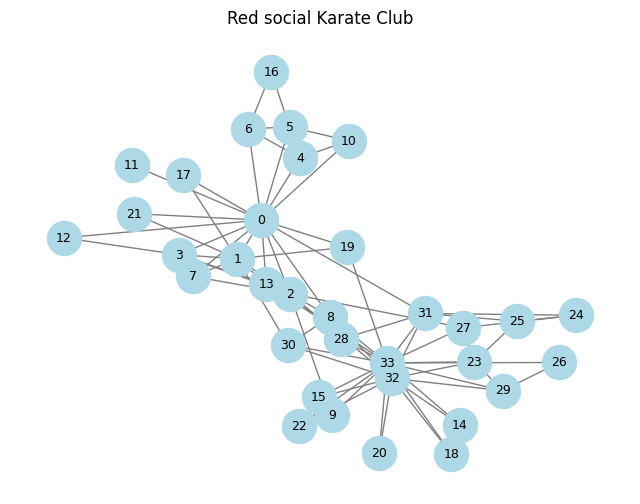

In [12]:
plt.figure(figsize=(8, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color="lightblue",
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Red social Karate Club")
plt.axis("off")
plt.show()

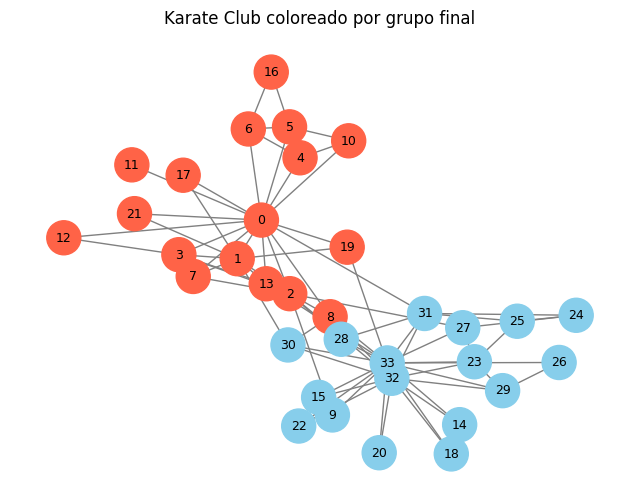

In [25]:
## 4. Comunidades del club
club_labels = nx.get_node_attributes(G, "club")
node_colors = [
    "tomato" if club_labels[n] == "Mr. Hi" else "skyblue"
    for n in G.nodes()
]
plt.figure(figsize=(8, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Karate Club coloreado por grupo final")
plt.axis("off")
plt.show()

Número de comunidades detectadas: 3
Comunidad 0: [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Comunidad 1: [1, 2, 3, 7, 9, 12, 13, 17, 21]
Comunidad 2: [0, 4, 5, 6, 10, 11, 16, 19]


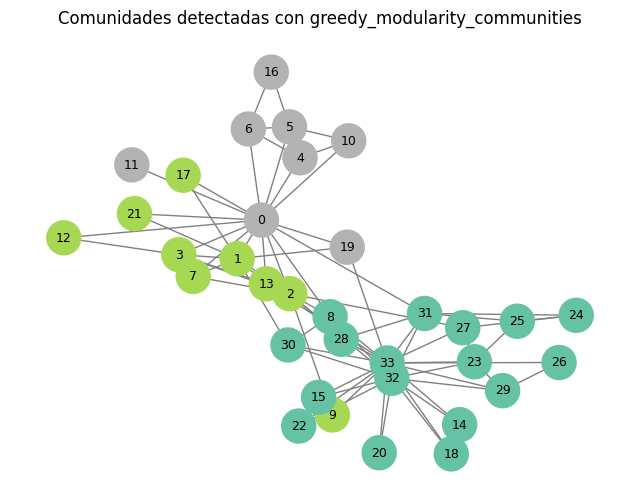

In [ ]:
# Intentamos predecir comunidades con algoritmos de detección de comunidades simples
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities

G = nx.karate_club_graph()

# Detectar comunidades
communities = greedy_modularity_communities(G)

print(f"Número de comunidades detectadas: {len(communities)}")
for i, c in enumerate(communities):
    print(f"Comunidad {i}: {sorted(c)}")

# Crear mapa nodo -> comunidad
node_to_community = {}
for i, community in enumerate(communities):
    for node in community:
        node_to_community[node] = i

# Colores
colors = [node_to_community[n] for n in G.nodes()]


plt.figure(figsize=(8,6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=colors,
    cmap=plt.cm.Set2,
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Comunidades detectadas con greedy_modularity_communities")
plt.axis("off")
plt.show()


In [ ]:
## 5. Nodos más conectados y más centrales
degrees = dict(G.degree())
df_nodes = pd.DataFrame({
    "node": list(G.nodes()),
    "club": [club_labels[n] for n in G.nodes()],
    "degree": [degrees[n] for n in G.nodes()]
})

df_nodes.sort_values("degree", ascending=False).head(10)

,node,club,degree
33,33,Officer,17
0,0,Mr. Hi,16
32,32,Officer,12
2,2,Mr. Hi,10
1,1,Mr. Hi,9
3,3,Mr. Hi,6
31,31,Officer,6
23,23,Officer,5
8,8,Mr. Hi,5
13,13,Mr. Hi,5


In [16]:
betweenness = nx.betweenness_centrality(G)

df_nodes["betweenness"] = df_nodes["node"].map(betweenness)
df_nodes.sort_values("betweenness", ascending=False).head(10)


,node,club,degree,betweenness
0,0,Mr. Hi,16,0.437635
33,33,Officer,17,0.304075
32,32,Officer,12,0.145247
2,2,Mr. Hi,10,0.143657
31,31,Officer,6,0.138276
8,8,Mr. Hi,5,0.055927
1,1,Mr. Hi,9,0.053937
13,13,Mr. Hi,5,0.045863
19,19,Mr. Hi,3,0.032475
5,5,Mr. Hi,4,0.029987


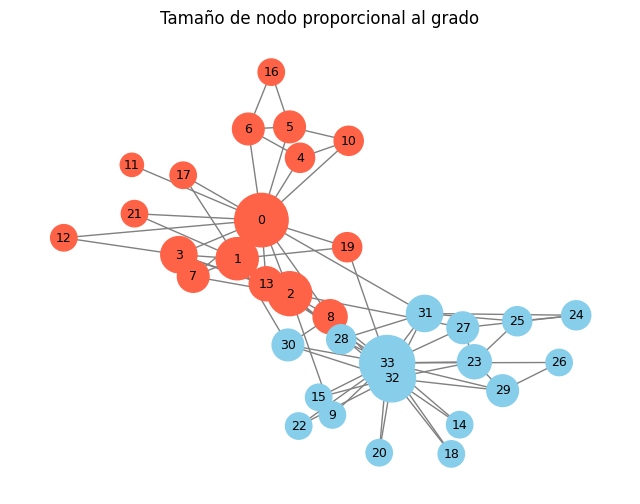

In [17]:
node_sizes = [200 + degrees[n] * 80 for n in G.nodes()]

plt.figure(figsize=(8, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    edge_color="gray",
    node_size=node_sizes,
    font_size=9
)
plt.title("Tamaño de nodo proporcional al grado")
plt.axis("off")
plt.show()

In [ ]:
## 6. El vecindario de un nodo
node = 0
neighbors = list(G.neighbors(node))
print(f"Vecinos de {node}: {neighbors}")
print(f"Número de vecinos de {node}: {len(neighbors)}")

Vecinos de 0: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
Número de vecinos de 0: 16


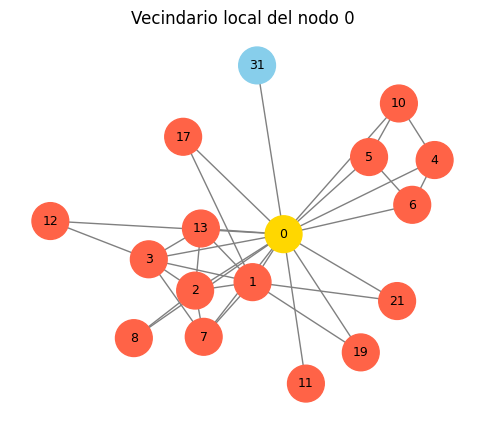

In [19]:
sub_nodes = [node] + neighbors
H = G.subgraph(sub_nodes)

pos_H = nx.spring_layout(H, seed=42)

colors_H = [
    "gold" if n == node else ("tomato" if club_labels[n] == "Mr. Hi" else "skyblue")
    for n in H.nodes()
]

plt.figure(figsize=(6, 5))
nx.draw_networkx(
    H,
    pos=pos_H,
    with_labels=True,
    node_color=colors_H,
    edge_color="gray",
    node_size=700,
    font_size=9
)
plt.title(f"Vecindario local del nodo {node}")
plt.axis("off")
plt.show()

In [ ]:
df_nodes["neighbors_mrhi"] = [
    sum(1 for nb in G.neighbors(n) if club_labels[nb] == "Mr. Hi")
    for n in G.nodes()
]

df_nodes["neighbors_officer"] = [
    sum(1 for nb in G.neighbors(n) if club_labels[nb] == "Officer")
    for n in G.nodes()
]


,node,club,degree,betweenness,neighbors_mrhi,neighbors_officer
0,0,Mr. Hi,16,0.437635,15,1
1,1,Mr. Hi,9,0.053937,8,1
2,2,Mr. Hi,10,0.143657,6,4
3,3,Mr. Hi,6,0.011909,6,0
4,4,Mr. Hi,3,0.000631,3,0
5,5,Mr. Hi,4,0.029987,4,0
6,6,Mr. Hi,4,0.029987,4,0
7,7,Mr. Hi,4,0.000000,4,0
8,8,Mr. Hi,5,0.055927,2,3
9,9,Officer,2,0.000848,1,1


In [21]:
df_nodes[["node", "club", "degree", "neighbors_mrhi", "neighbors_officer"]].head(15)

,node,club,degree,neighbors_mrhi,neighbors_officer
0,0,Mr. Hi,16,15,1
1,1,Mr. Hi,9,8,1
2,2,Mr. Hi,10,6,4
3,3,Mr. Hi,6,6,0
4,4,Mr. Hi,3,3,0
5,5,Mr. Hi,4,4,0
6,6,Mr. Hi,4,4,0
7,7,Mr. Hi,4,4,0
8,8,Mr. Hi,5,2,3
9,9,Officer,2,1,1


In [ ]:
## 7. Una regla simple basada en vecinos
def predict_by_neighbor_majority(node):
    neighbors = list(G.neighbors(node))
    if not neighbors:
        return None
    
    mrhi = sum(1 for nb in neighbors if club_labels[nb] == "Mr. Hi")
    officer = sum(1 for nb in neighbors if club_labels[nb] == "Officer")
    
    return "Mr. Hi" if mrhi >= officer else "Officer"

df_nodes["pred_majority_neighbors"] = df_nodes["node"].apply(predict_by_neighbor_majority)
df_nodes["correct"] = df_nodes["pred_majority_neighbors"] == df_nodes["club"]

df_nodes[["node", "club", "pred_majority_neighbors", "correct"]].head(15)
print("Accuracy:", df_nodes["correct"].mean())

Accuracy: 0.9117647058823529


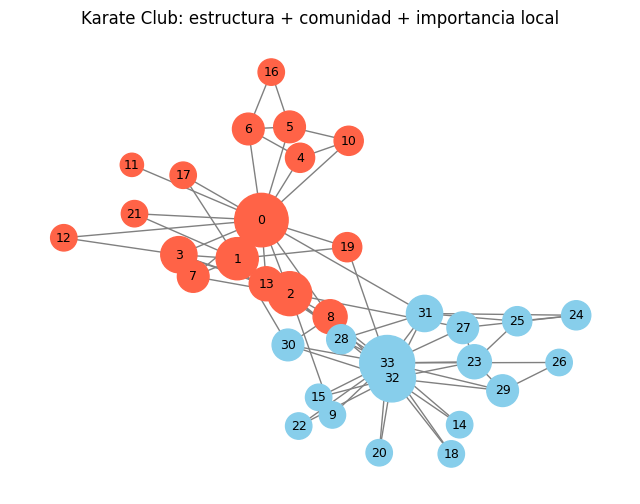

In [ ]:
## 8. Qué tiene que ver esto con las GNN
plt.figure(figsize=(8, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    edge_color="gray",
    node_size=[200 + 80 * degrees[n] for n in G.nodes()],
    font_size=9
)
plt.title("Karate Club: estructura + comunidad + importancia local")
plt.axis("off")
plt.show()